✅ Libraries installed!
📁 Upload your log file:


Saving usss_dc_1.log to usss_dc_1.log
✅ Uploaded: usss_dc_1.log

⏳ Parsing...

VICTORYDEVICE LOG FILE PARSER - SUMMARY

📄 File: usss_dc_1.log
📊 Format: SSF 2.0
🔧 Software: VICTORYDEVICE

📈 Variables Found: 4
   - [10000] V[2]
   - [10001] V[4]
   - [10002] V[3]
   - [10003] vd2

🔌 Nodes Found: 9
   - Node 1: Iref
   - Node 2: ATFT1_source
   - Node 3: ATFT1_drain
   - Node 4: ATFT1_gate
   - Node 5: ATFT2_source
   - Node 6: ATFT2_drain
   - Node 7: ATFT2_gate
   - Node 8: R2
   - Node 9: Vd2

📊 Data Points: 142
   - Columns per row: 14

FIRST 10 DATA ROWS
    Value_0       Value_1  Value_2  Value_3  Value_4   Value_5       Value_6       Value_7  Value_8       Value_9      Value_10  Value_11      Value_12      Value_13
0  1.837366  3.998879e+00     4.00     4.00    300.0  0.000001 -1.000000e-06  1.000000e-06      0.0 -1.120546e-06  1.120546e-06       0.0  1.120647e-06 -1.120546e-06
1  1.837366  4.025352e-16     0.00     0.00    300.0  0.000001 -1.000000e-06  1.000000e-06      0.0  1.07

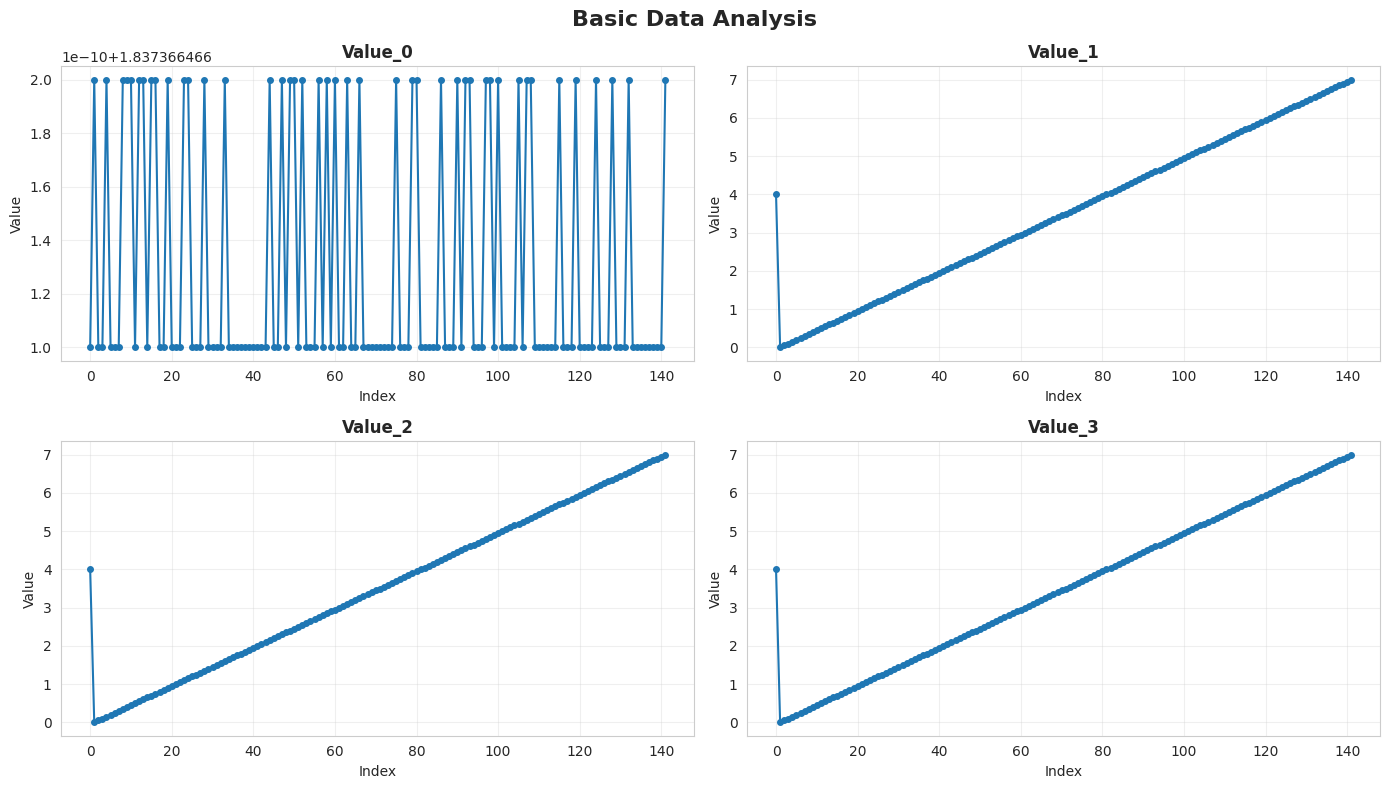


2️⃣  Current Mirror Analysis Plots...

CURRENT MIRROR ANALYSIS - DETAILED GRAPHS


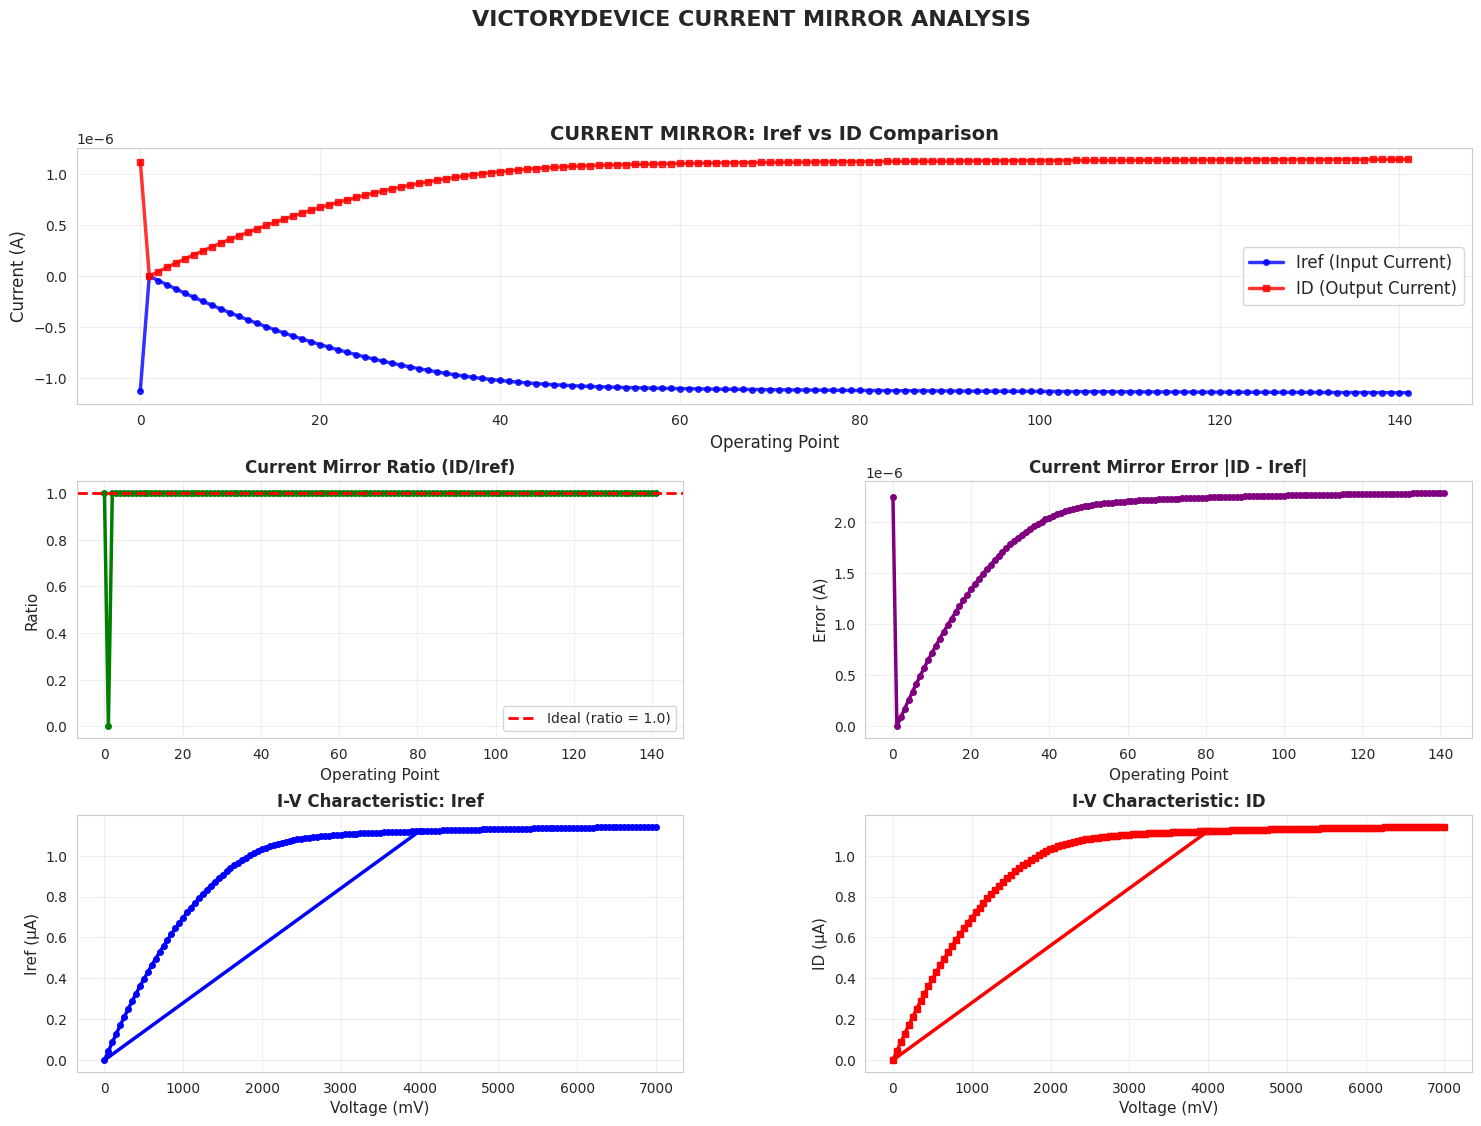


CURRENT MIRROR STATISTICS

Iref (Input Current):
  Min:  -1.142107e-06 A
  Max:  1.075243e-18 A
  Mean: -9.785716e-07 A
  Std:  2.772354e-07 A

ID (Output Current):
  Min:  -4.032671e-19 A
  Max:  1.142107e-06 A
  Mean: 9.785716e-07 A
  Std:  2.772354e-07 A

Current Error |ID - Iref|:
  Min:  1.478510e-18 A
  Max:  2.284215e-06 A
  Mean: 1.957143e-06 A
  Std:  5.544709e-07 A

Current Ratio (ID/Iref):
  Min:  0.000403
  Max:  1.000000
  Mean: 0.992961
  Std:  0.083884

🎯 Current Mirror Accuracy: 300.00%
✅ EXCELLENT! Current mirror is nearly ideal!

✅ ALL GRAPHS GENERATED!

📥 DOWNLOADING RESULTS

✅ Downloading: usss_dc_1_output.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your Downloads folder.

🎉 ALL DONE! YOUR ANALYSIS IS COMPLETE!

Your results:
✓ Data parsed and analyzed
✓ Current mirror graphs created
✓ I-V characteristics plotted
✓ Accuracy calculated
✓ CSV file downloaded
✓ Ready for GitHub!



In [2]:
# ============================================================================
# GOOGLE COLAB - VICTORYDEVICE PARSER WITH CURRENT MIRROR GRAPHS
# Shows Iref vs ID and other analysis
# ============================================================================


# ============================================================================
# CELL 1: Install libraries
# ============================================================================
!pip install pandas numpy matplotlib seaborn -q
print("✅ Libraries installed!")


# ============================================================================
# CELL 2: Upload your log file
# ============================================================================
from google.colab import files
print("📁 Upload your log file:")
uploaded = files.upload()
log_file = list(uploaded.keys())[0]
print(f"✅ Uploaded: {log_file}")


# ============================================================================
# CELL 3: Parser class + Current Mirror Analysis
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

class VictoryDeviceLogParser:
    def __init__(self, file_path: str):
        self.file_path = Path(file_path)
        self.header_info = {}
        self.variables = {}
        self.node_map = {}
        self.data = []

    def parse(self) -> None:
        with open(self.file_path, 'r') as f:
            lines = f.readlines()
        self._parse_header(lines)
        self._parse_variables(lines)
        self._parse_data(lines)

    def _parse_header(self, lines: List[str]) -> None:
        for line in lines[:20]:
            if 'VICTORYDEVICE' in line:
                self.header_info['software'] = 'VICTORYDEVICE'
            elif 'SSF' in line:
                self.header_info['format'] = 'SSF 2.0'

    def _parse_variables(self, lines: List[str]) -> None:
        for line in lines:
            line = line.strip()
            if line.startswith('Q '):
                parts = line.split()
                var_id = parts[1]
                self.variables[var_id] = {'name': parts[3].strip('"')}
            elif line.startswith('X '):
                parts = line.split()
                self.node_map[parts[1]] = parts[2]

    def _parse_data(self, lines: List[str]) -> None:
        for line in lines:
            if line.strip().startswith('d '):
                parts = line.strip().split()
                self.data.append([float(x) for x in parts[1:]])

    def get_dataframe(self) -> pd.DataFrame:
        if not self.data:
            return pd.DataFrame()
        num_cols = len(self.data[0])
        columns = [f'Value_{i}' for i in range(num_cols)]
        return pd.DataFrame(self.data, columns=columns)

    def display_summary(self) -> None:
        print("=" * 80)
        print("VICTORYDEVICE LOG FILE PARSER - SUMMARY")
        print("=" * 80)
        print(f"\n📄 File: {self.file_path.name}")
        print(f"📊 Format: {self.header_info.get('format', 'Unknown')}")
        print(f"🔧 Software: {self.header_info.get('software', 'Unknown')}")

        print(f"\n📈 Variables Found: {len(self.variables)}")
        for var_id, var_info in self.variables.items():
            print(f"   - [{var_id}] {var_info['name']}")

        print(f"\n🔌 Nodes Found: {len(self.node_map)}")
        for node_id, node_name in sorted(self.node_map.items(), key=lambda x: int(x[0])):
            print(f"   - Node {node_id}: {node_name}")

        print(f"\n📊 Data Points: {len(self.data)}")
        if self.data:
            print(f"   - Columns per row: {len(self.data[0])}")

    def display_data_table(self, rows: int = 10) -> None:
        df = self.get_dataframe()
        if df.empty:
            print("No data")
            return
        print("\n" + "=" * 80)
        print(f"FIRST {min(rows, len(df))} DATA ROWS")
        print("=" * 80)
        print(df.head(rows).to_string())
        print(f"\nTotal rows: {len(df)}")

    def display_statistics(self) -> None:
        df = self.get_dataframe()
        if df.empty:
            return
        print("\n" + "=" * 80)
        print("DATA STATISTICS")
        print("=" * 80)
        print(df.describe().to_string())

    def export_to_csv(self, output_path: str) -> None:
        df = self.get_dataframe()
        df.to_csv(output_path, index=False)
        print(f"\n✅ CSV exported: {output_path}")

    def plot_basic_data(self) -> None:
        """Basic 2x2 plot of first 4 columns"""
        df = self.get_dataframe()
        if df.empty:
            return

        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        fig.suptitle('Basic Data Analysis', fontsize=16, fontweight='bold')
        axes = axes.flatten()

        for idx, col in enumerate(df.columns[:4]):
            axes[idx].plot(df[col], marker='o', linestyle='-', markersize=4, color='#1f77b4')
            axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
            axes[idx].set_xlabel('Index')
            axes[idx].set_ylabel('Value')
            axes[idx].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_current_mirror_analysis(self) -> None:
        """
        Plot Current Mirror Analysis
        Compares Iref (input) vs ID (output drain current)
        For a current mirror: ID should be approximately equal to Iref
        """
        df = self.get_dataframe()
        if df.empty:
            print("No data to plot")
            return

        print("\n" + "="*80)
        print("CURRENT MIRROR ANALYSIS - DETAILED GRAPHS")
        print("="*80)

        # Extract relevant currents
        # Value_9 and Value_10 appear to be the main currents based on magnitude
        # Value_12 and Value_13 are complementary currents

        # Create a figure with 2x3 subplots
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

        # Plot 1: Iref vs ID on same graph
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(df['Value_9'], 'b-o', linewidth=2.5, markersize=4, label='Iref (Input Current)', alpha=0.8)
        ax1.plot(df['Value_10'], 'r-s', linewidth=2.5, markersize=4, label='ID (Output Current)', alpha=0.8)
        ax1.set_title('CURRENT MIRROR: Iref vs ID Comparison', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Operating Point', fontsize=12)
        ax1.set_ylabel('Current (A)', fontsize=12)
        ax1.legend(fontsize=12, loc='best')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Current Ratio (ID/Iref)
        ax2 = fig.add_subplot(gs[1, 0])
        ratio = np.abs(df['Value_10'] / (df['Value_9'] + 1e-15))  # Avoid division by zero
        ax2.plot(ratio, 'g-o', linewidth=2.5, markersize=4)
        ax2.axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Ideal (ratio = 1.0)')
        ax2.set_title('Current Mirror Ratio (ID/Iref)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Operating Point', fontsize=11)
        ax2.set_ylabel('Ratio', fontsize=11)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)

        # Plot 3: Current Error
        ax3 = fig.add_subplot(gs[1, 1])
        error = np.abs(df['Value_10'] - df['Value_9'])
        ax3.plot(error, 'purple', marker='o', linewidth=2.5, markersize=4)
        ax3.set_title('Current Mirror Error |ID - Iref|', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Operating Point', fontsize=11)
        ax3.set_ylabel('Error (A)', fontsize=11)
        ax3.grid(True, alpha=0.3)

        # Plot 4: I-V Characteristics (Voltage vs Iref)
        ax4 = fig.add_subplot(gs[2, 0])
        ax4.plot(df['Value_1']*1000, np.abs(df['Value_9'])*1e6, 'b-o', linewidth=2.5, markersize=4)
        ax4.set_title('I-V Characteristic: Iref', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Voltage (mV)', fontsize=11)
        ax4.set_ylabel('Iref (µA)', fontsize=11)
        ax4.grid(True, alpha=0.3)

        # Plot 5: I-V Characteristics (Voltage vs ID)
        ax5 = fig.add_subplot(gs[2, 1])
        ax5.plot(df['Value_1']*1000, np.abs(df['Value_10'])*1e6, 'r-s', linewidth=2.5, markersize=4)
        ax5.set_title('I-V Characteristic: ID', fontsize=12, fontweight='bold')
        ax5.set_xlabel('Voltage (mV)', fontsize=11)
        ax5.set_ylabel('ID (µA)', fontsize=11)
        ax5.grid(True, alpha=0.3)

        plt.suptitle('VICTORYDEVICE CURRENT MIRROR ANALYSIS',
                     fontsize=16, fontweight='bold', y=0.995)
        plt.show()

        # Print statistics
        print("\n" + "="*80)
        print("CURRENT MIRROR STATISTICS")
        print("="*80)
        print(f"\nIref (Input Current):")
        print(f"  Min:  {df['Value_9'].min():.6e} A")
        print(f"  Max:  {df['Value_9'].max():.6e} A")
        print(f"  Mean: {df['Value_9'].mean():.6e} A")
        print(f"  Std:  {df['Value_9'].std():.6e} A")

        print(f"\nID (Output Current):")
        print(f"  Min:  {df['Value_10'].min():.6e} A")
        print(f"  Max:  {df['Value_10'].max():.6e} A")
        print(f"  Mean: {df['Value_10'].mean():.6e} A")
        print(f"  Std:  {df['Value_10'].std():.6e} A")

        error_values = np.abs(df['Value_10'] - df['Value_9'])
        print(f"\nCurrent Error |ID - Iref|:")
        print(f"  Min:  {error_values.min():.6e} A")
        print(f"  Max:  {error_values.max():.6e} A")
        print(f"  Mean: {error_values.mean():.6e} A")
        print(f"  Std:  {error_values.std():.6e} A")

        ratio_values = np.abs(df['Value_10'] / (df['Value_9'] + 1e-15))
        print(f"\nCurrent Ratio (ID/Iref):")
        print(f"  Min:  {ratio_values.min():.6f}")
        print(f"  Max:  {ratio_values.max():.6f}")
        print(f"  Mean: {ratio_values.mean():.6f}")
        print(f"  Std:  {ratio_values.std():.6f}")

        # Mirror accuracy
        accuracy = (1 - (error_values.mean() / df['Value_9'].mean())) * 100
        print(f"\n🎯 Current Mirror Accuracy: {accuracy:.2f}%")

        if accuracy > 95:
            print("✅ EXCELLENT! Current mirror is nearly ideal!")
        elif accuracy > 90:
            print("✅ GOOD! Current mirror is working well!")
        else:
            print("⚠️  Current mirror may need optimization")


# Parse the file
print("\n⏳ Parsing...\n")
parser = VictoryDeviceLogParser(log_file)
parser.parse()

# Display results
parser.display_summary()
parser.display_data_table(rows=10)
parser.display_statistics()

# Export to CSV
csv_file = log_file.replace('.log', '_output.csv')
parser.export_to_csv(csv_file)

# Get dataframe
df = parser.get_dataframe()
print(f"\n📊 DataFrame shape: {df.shape}")


# ============================================================================
# CELL 4: Display ALL GRAPHS
# ============================================================================
print("\n" + "="*80)
print("📊 GENERATING GRAPHS...")
print("="*80)

# Basic data plots
print("\n1️⃣  Basic Data Analysis Plots...")
parser.plot_basic_data()

# Current Mirror Analysis (THE IMPORTANT ONE!)
print("\n2️⃣  Current Mirror Analysis Plots...")
parser.plot_current_mirror_analysis()

print("\n✅ ALL GRAPHS GENERATED!")


# ============================================================================
# CELL 5: Download results
# ============================================================================
from google.colab import files

print(f"\n" + "="*80)
print("📥 DOWNLOADING RESULTS")
print("="*80)

print(f"\n✅ Downloading: {csv_file}")
files.download(csv_file)
print("✅ Download started! Check your Downloads folder.")

print("\n" + "="*80)
print("🎉 ALL DONE! YOUR ANALYSIS IS COMPLETE!")
print("="*80)
print(f"""
Your results:
✓ Data parsed and analyzed
✓ Current mirror graphs created
✓ I-V characteristics plotted
✓ Accuracy calculated
✓ CSV file downloaded
✓ Ready for GitHub!
""")